

## Tema del Proyecto


> Predicción de ventas globales de videojuegos utilizando técnicas de regresión y aprendizaje automático supervisado.
Este dataset contiene una lista de videojuegos con ventas superiores a 100.000 copias. El Objetivo es el analisis de algunas estadisticas e informacion pertinente que nos pueda proveer este dataset. Pero primero veamos de que trata cada columna.

Rank - Ranking de venta en general

Name - el nombre de los juegos

Platform - Plataforma donde se lanzó el juego (ejemplo. PC,PS4, etc.)

Year - año en el que se lanzó el juego

Genre - genero del juego

Publisher - publicador del juego

NA_Sales - ventas en NorteAmerica (en millones)

EU_Sales - ventas en Europa (en millones)

JP_Sales - ventas en Japón (en millones)

Other_Sales - ventas en el resto del mundo (en millones)

Global_Sales - Total de ventas globales.

---

## Descripción del Proyecto


[Este proyecto busca
Predecir el rendimiento comercial: Anticipar el potencial de ventas de nuevos títulos o prototipos antes de su lanzamiento.

Optimizar la inversión y el marketing: Decidir dónde enfocar recursos de desarrollo y publicidad, al tener una estimación del retorno esperado.

Identificar factores de éxito: Comprender qué características (género, plataforma, año de lanzamiento) tienen el mayor impacto en las ventas]

---

## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), utilizada ampliamente para abordar proyectos de ciencia de datos y machine learning. Se compone de seis fases fundamentales:

[1 Comprensión del Negocio: Definir los objetivos de negocio y la necesidad de predecir ventas de videojuegos.

2 Comprensión de los Datos: Cargar y explorar el dataset de ventas para entender su contenido y calidad.

3 Preparación de los Datos: Limpiar, transformar y preparar los datos para el entrenamiento de modelos de Machine Learning (incluyendo codificación y escalado).

4 Modelado: Seleccionar, implementar y entrenar algoritmos de Machine Learning (ej., Regresión Lineal, Árbol de Decisión, SVM) para predecir ventas.

5 Evaluación: Evaluar rigurosamente el rendimiento del modelo utilizando métricas adecuadas.

6 Despliegue: Presentar las conclusiones, las limitaciones del modelo y las recomendaciones para su aplicación práctica]



## 1. Comprensión del Negocio




El objetivo principal es desarrollar un modelo predictivo que permita estimar las ventas globales de un videojuego basándose en sus características clave.
Se busca que este modelo ayude a las empresas desarrolladoras y publicadoras de videojuegos a:

1 Predecir el rendimiento comercial: Anticipar el potencial de ventas de nuevos títulos o prototipos antes de su lanzamiento.
2 Optimizar la inversión y el marketing: Decidir dónde enfocar recursos de desarrollo y publicidad, al tener una estimación del retorno esperado.
3 Identificar factores de éxito: Comprender qué características (género, plataforma, año de lanzamiento) tienen el mayor impacto en las ventas

## 2. Comprensión de los Datos

 El dataset utilizado, vgsales.csv, Contiene un total de 16,598 registros (filas) y 11 columnas (características).

Variables Objetivo (Target): La variable principal que buscamos predecir es Global_Sales (ventas totales en el mundo en millones de dólares).

Variables Predictoras (Features): Las características utilizadas para entrenar el modelo son Platform, Year, Genre, y Publisher. Las columnas Rank y Name son identificadores o características de alta cardinalidad que no se usarán directamente para la predicción en esta etapa.

Tipos de Datos:
Numéricas: Rank, Year, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales.

Categóricas: Name, Platform, Genre, Publisher

In [ ]:
import pandas as pd
from IPython.display import display, HTML

# --- Carga del dataset  ---
try:
    df = pd.read_csv('vgsales.csv')
    print("Dataset 'vgsales.csv' cargado exitosamente desde el entorno de Colab.")
except FileNotFoundError:
    print("Error: 'vgsales.csv' no encontrado en el directorio actual de Colab.")
    print("Asegúrate de haber subido el archivo a la sesión actual o verifica el nombre.")
    from google.colab import files
    uploaded = files.upload()
    if 'vgsales.csv' in uploaded:
        df = pd.read_csv('vgsales.csv')
        print("Archivo subido y cargado exitosamente.")
    else:
        print("No se pudo cargar el archivo.")
        df = pd.DataFrame() # Crear un dataframe vacío para evitar errores posteriores si no se carga

# Verificar si el dataframe se cargó correctamente antes de continuar
if not df.empty:
    # --- Primeras 5 filas del dataset (con estilo) ---
    print("\n--- Primeras 5 filas del dataset ---")
    display(df.head().style.set_caption("Vista Previa de los Datos").background_gradient(cmap='Blues'))

    print("\n--- Información general del dataset (df.info() ya es bastante claro, no se puede estilizar directamente con .style) ---")
    df.info()

    # --- Estadísticas descriptivas de las variables numéricas (con estilo) ---
    print("\n--- Estadísticas descriptivas de las variables numéricas ---")
    display(df.describe().style.set_caption("Estadísticas Descriptivas").background_gradient(cmap='PuBu', axis=1).format(precision=2))

    # --- Conteo de valores nulos por columna (con estilo) ---
    print("\n--- Conteo de valores nulos por columna ---")
    # Convertimos la Serie de isnull().sum() a un DataFrame para poder estilizarla
    null_counts = df.isnull().sum().rename('Cantidad de Nulos').to_frame()
    display(null_counts.style.set_caption("Conteo de Valores Nulos").highlight_max(axis=0, color='red').background_gradient(cmap='Oranges'))

    print("\n--- Vista de la distribución de Nulos (con barras y formato) ---")
    # Filtramos solo las columnas con nulos para una mejor visualización
    null_percentage = (df.isnull().sum() / len(df) * 100).rename('Porcentaje de Nulos').to_frame()
    null_info = pd.concat([null_counts, null_percentage], axis=1).sort_values(by='Porcentaje de Nulos', ascending=False)

    display(null_info.style
            .set_caption("Detalle de Valores Nulos por Columna")
            .format({"Porcentaje de Nulos": "{:.2f}%"}) # Formato de porcentaje
            .background_gradient(cmap='YlOrRd', subset=['Porcentaje de Nulos']) # Gradiente de color en la columna de porcentaje
            .highlight_max(subset=['Porcentaje de Nulos'], color='red') # Resalta el máximo en rojo
            .set_properties(**{'text-align': 'center'}) # Centrar texto en celdas
           )


else:
    print("\nEl DataFrame no se cargó. No se pueden mostrar las estadísticas.")

Dataset 'vgsales.csv' cargado exitosamente desde el entorno de Colab.

--- Primeras 5 filas del dataset ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.000000,Sports,Nintendo,41.490000,29.020000,3.770000,8.460000,82.740000
1,2,Super Mario Bros.,NES,1985.000000,Platform,Nintendo,29.080000,3.580000,6.810000,0.770000,40.240000
2,3,Mario Kart Wii,Wii,2008.000000,Racing,Nintendo,15.850000,12.880000,3.790000,3.310000,35.820000
3,4,Wii Sports Resort,Wii,2009.000000,Sports,Nintendo,15.750000,11.010000,3.280000,2.960000,33.000000
4,5,Pokemon Red/Pokemon Blue,GB,1996.000000,Role-Playing,Nintendo,11.270000,8.890000,10.220000,1.000000,31.370000



--- Información general del dataset (df.info() ya es bastante claro, no se puede estilizar directamente con .style) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB

--- Estadísticas descriptivas de las variables numéricas ---


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.00,16327.00,16598.00,16598.00,16598.00,16598.00,16598.00
mean,8300.61,2006.41,0.26,0.15,0.08,0.05,0.54
std,4791.85,5.83,0.82,0.51,0.31,0.19,1.56
min,1.00,1980.00,0.00,0.00,0.00,0.00,0.01
25%,4151.25,2003.00,0.00,0.00,0.00,0.00,0.06
50%,8300.50,2007.00,0.08,0.02,0.00,0.01,0.17
75%,12449.75,2010.00,0.24,0.11,0.04,0.04,0.47
max,16600.00,2020.00,41.49,29.02,10.22,10.57,82.74



--- Conteo de valores nulos por columna ---


,Cantidad de Nulos
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0



--- Vista de la distribución de Nulos (con barras y formato) ---


,Cantidad de Nulos,Porcentaje de Nulos
Year,271,1.63%
Publisher,58,0.35%
Rank,0,0.00%
Platform,0,0.00%
Name,0,0.00%
Genre,0,0.00%
NA_Sales,0,0.00%
EU_Sales,0,0.00%
JP_Sales,0,0.00%
Other_Sales,0,0.00%


In [ ]:
print(df['Global_Sales'].min())
print(df['Global_Sales'].max())


0.01
82.74


## 3. Preparación de los Datos
Detalle los pasos de limpieza y transformación de datos.

- Eliminación de nulos
- Corregir plataforma si es necesario
- Conversión de categorías
-  Revisar que Global_Sales esté en la escala original

En esta etapa se realiza una limpieza inicial del dataset. Se eliminan registros con valores nulos, se corrigen errores en plataformas y se transforman variables categóricas para facilitar el modelado posterior.



In [ ]:
# Eliminar nulos
df = df.dropna()

df_para_exportar = df.copy()

# Corregir plataforma si es necesario
df['Platform'] = df['Platform'].replace({'PS2 ': 'PS2'})

# Convertir columnas categóricas
categorical_columns = ['Platform', 'Genre', 'Publisher']
for col in categorical_columns:
    df[col] = df[col].astype('category')

# Revisar que Global_Sales esté en la escala original
print(df['Global_Sales'].describe())


count    16291.000000
mean         0.540910
std          1.567345
min          0.010000
25%          0.060000
50%          0.170000
75%          0.480000
max         82.740000
Name: Global_Sales, dtype: float64


/tmp/ipython-input-3-1395627458.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Platform'] = df['Platform'].replace({'PS2 ': 'PS2'})
/tmp/ipython-input-3-1395627458.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype('category')
/tmp/ipython-input-3-1395627458.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

#### 3.1 Depuración de Datos

- Detección y tratamiento de outliers
- Corrección de errores de tipeo

[Se eliminan los valores nulos restantes, se identifican posibles valores atípicos (outliers) en las ventas globales y se revisan errores de tipeo o inconsistencias en las variables categóricas.

Detectando posibles outliers en Global_Sales...


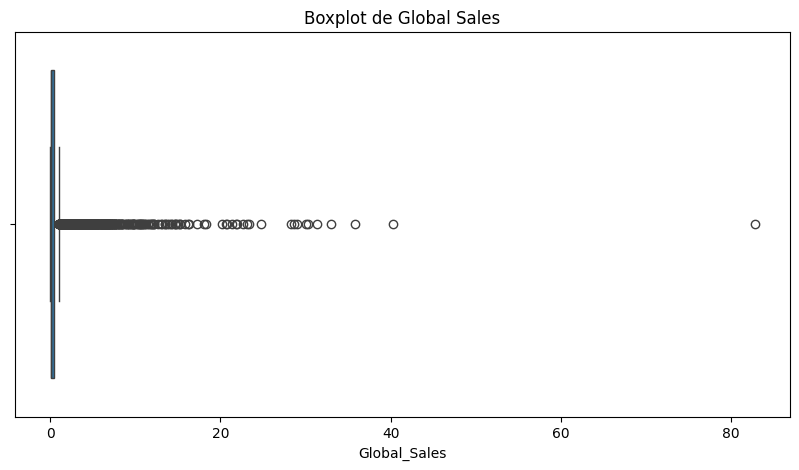

Corrigiendo errores conocidos en la columna 'Platform'...


In [ ]:
# Escriba aqui sus codigos
# --- Detección de valores atípicos (outliers) usando boxplot ---
import seaborn as sns
import matplotlib.pyplot as plt

print("Detectando posibles outliers en Global_Sales...")
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Global_Sales'])
plt.title("Boxplot de Global Sales")
plt.show()

# --- Corrección de errores de tipeo (si detectas inconsistencias manuales, ej. plataformas mal escritas) ---
print("Corrigiendo errores conocidos en la columna 'Platform'...")
df['Platform'] = df['Platform'].replace({'PS2 ': 'PS2'})  # Ejemplo de espacio extra


In [ ]:
print("Detectando posibles outliers en Global_Sales...")

# Calcular los percentiles (Q1 y Q3) y el rango intercuartílico (IQR)
q1 = df['Global_Sales'].quantile(0.25)
q3 = df['Global_Sales'].quantile(0.75)
iqr = q3 - q1

# Definir límites para considerar outliers
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Contar posibles outliers
outliers = df[(df['Global_Sales'] < limite_inferior) | (df['Global_Sales'] > limite_superior)]

print(f"Valores fuera de rango detectados: {len(outliers)} registros.")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print("⚠️ Revisa si quieres eliminarlos o dejarlos en el análisis.")

# --- Corrección de errores de tipeo ---
print("Corrigiendo errores conocidos en la columna 'Platform'...")
df['Platform'] = df['Platform'].replace({'PS2 ': 'PS2'})  # Ejemplo de espacio extra


Detectando posibles outliers en Global_Sales...
Valores fuera de rango detectados: 1826 registros.
Límite inferior: -0.57
Límite superior: 1.11
⚠️ Revisa si quieres eliminarlos o dejarlos en el análisis.
Corrigiendo errores conocidos en la columna 'Platform'...


#### 3.2 Encoding (si aplica)
se aplica label encoding en las variables categoricas, platform, genre, publisher.

In [ ]:
# Escriba aqui sus codigos

# --- Transformación de variables categóricas (LabelEncoding como ejemplo básico) ---
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_features = ['Platform', 'Genre', 'Publisher']

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # guardamos el encoder por si queremos invertirlo después

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,26,2006.0,10,359,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,11,1985.0,4,359,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,26,2008.0,6,359,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,26,2009.0,10,359,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,5,1996.0,7,359,11.27,8.89,10.22,1.00,31.37


## 4. Análisis Exploratorio
Histogramas para ver cómo se distribuyen tus ventas globales.

Una matriz de correlación para identificar cómo se relacionan las variables numéricas entre sí.

Un ajuste a una distribución normal para entender el patrón de tus ventas globales.

Distribución de las ventas globales:


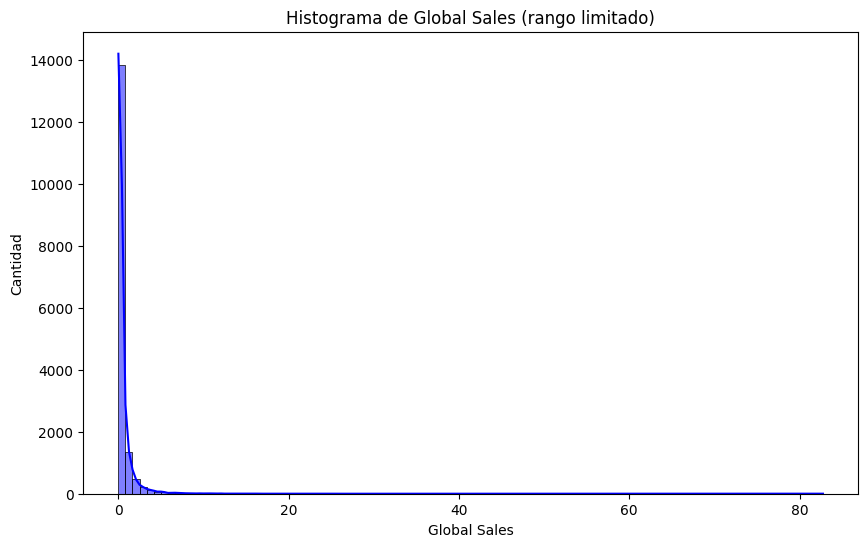

Correlación entre variables numéricas:


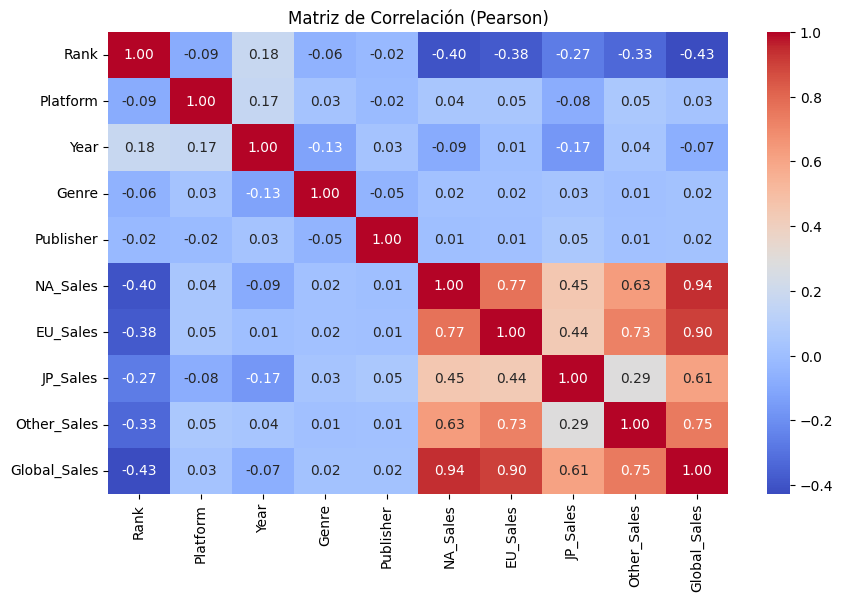

Distribución de Global Sales con curva normal...


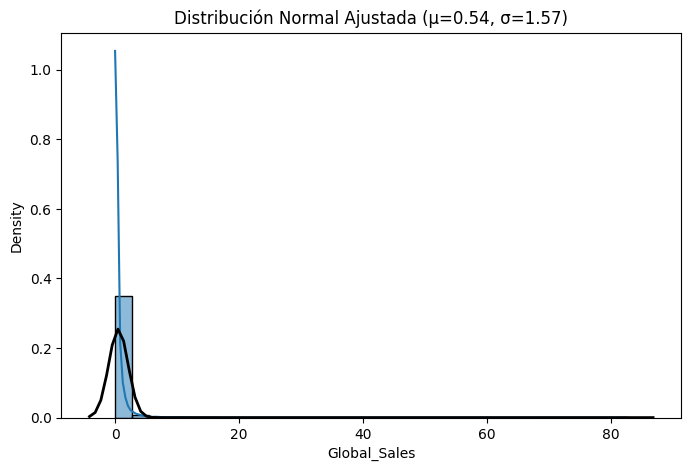

In [ ]:
# Escriba aqui sus codigos

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Histogramas ---
print("Distribución de las ventas globales:")
plt.figure(figsize=(10,6))
sns.histplot(df['Global_Sales'], kde=True, color='blue', bins=100)
plt.title("Histograma de Global Sales (rango limitado)")
plt.xlabel("Global Sales")
plt.ylabel("Cantidad")
plt.show()
# --- Matriz de correlación ---
print("Correlación entre variables numéricas:")

# Filtrar solo columnas numéricas
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
correlation = numeric_df.corr(method='pearson')  # solo numéricas
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación (Pearson)")
plt.show()

# --- Distribución normal o gaussiana (ejemplo para Global_Sales) ---
import scipy.stats as stats

print("Distribución de Global Sales con curva normal...")
plt.figure(figsize=(8,5))
sns.histplot(df['Global_Sales'], kde=True, stat="density", bins=30)
mu, std = stats.norm.fit(df['Global_Sales'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
plt.title(f"Distribución Normal Ajustada (μ={mu:.2f}, σ={std:.2f})")
plt.show()


## 5. Modelado
a continuacion revisaremos los modelos de regresion y veremos su puntiación, en el proceso nos daremos cuenta de que los porcentajes mas altos se encuentran en el knn y en el modelo de regresion lineal, por lo que evaluaremos ambos

In [ ]:
# Escriba aqui las importaciones de modelo necesarias (librerias de sklearn)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score # Para evaluar mejor

features = ['EU_Sales', 'NA_Sales' ]
X = df[features]
y = df['Global_Sales']





In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# --- 4. Inicializar y Entrenar Modelos de Regresión ---

# Diccionario con los modelos a entrenar
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42), # Fijar semilla para reproducibilidad
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Árbol de decisión": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Entrenamiento y evaluación
print("\n--- Resultados de los Modelos ---")
resultados = {}

for nombre, modelo in modelos.items():
    # Entrenar el modelo
    modelo.fit(X_train_scaled, y_train)

    # Predecir en el set de prueba
    y_pred = modelo.predict(X_test_scaled)

    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Guardar resultados
    resultados[nombre] = {"MSE": mse, "R2": r2}

    # Mostrar métricas
    print(f"\nModelo: {nombre}")
    print(f"  Error Cuadrático Medio (MSE): {mse:.4f}")
    print(f"  Coeficiente de Determinación (R2): {r2:.4f}")

# Resumen final
print("\n--- Resumen de Resultados ---")
for nombre, metricas in resultados.items():
    print(f"Modelo: {nombre} | MSE: {metricas['MSE']:.4f} | R2: {metricas['R2']:.4f}")



--- Resultados de los Modelos ---

Modelo: Regresión Lineal
  Error Cuadrático Medio (MSE): 0.1103
  Coeficiente de Determinación (R2): 0.9670

Modelo: Random Forest
  Error Cuadrático Medio (MSE): 0.5321
  Coeficiente de Determinación (R2): 0.8410

Modelo: KNN
  Error Cuadrático Medio (MSE): 0.6868
  Coeficiente de Determinación (R2): 0.7948

Modelo: SVR
  Error Cuadrático Medio (MSE): 1.6441
  Coeficiente de Determinación (R2): 0.5088

Modelo: Árbol de decisión
  Error Cuadrático Medio (MSE): 0.4864
  Coeficiente de Determinación (R2): 0.8547

Modelo: Gradient Boosting
  Error Cuadrático Medio (MSE): 0.5134
  Coeficiente de Determinación (R2): 0.8466

--- Resumen de Resultados ---
Modelo: Regresión Lineal | MSE: 0.1103 | R2: 0.9670
Modelo: Random Forest | MSE: 0.5321 | R2: 0.8410
Modelo: KNN | MSE: 0.6868 | R2: 0.7948
Modelo: SVR | MSE: 1.6441 | R2: 0.5088
Modelo: Árbol de decisión | MSE: 0.4864 | R2: 0.8547
Modelo: Gradient Boosting | MSE: 0.5134 | R2: 0.8466


## 6. Entrenamiento y Evaluación
En esta etapa, se entrena el modelo de regresión de K-Vecinos más Cercanos (KNN) utilizando los datos de entrenamiento preparados. Una vez entrenado, el modelo se usa para predecir las ventas globales en un conjunto de datos de prueba. Finalmente, se evalúa su rendimiento calculando el Error Cuadrático Medio (MSE) y el Coeficiente de Determinación (R2), que indican qué tan precisas son las predicciones del modelo. Los gráficos de dispersión también ayudan a visualizar la calidad de las predicciones y el comportamiento de los errores del modelo.

Evaluación del modelo KNN:
-MSE: 0.69
- R²: 0.79


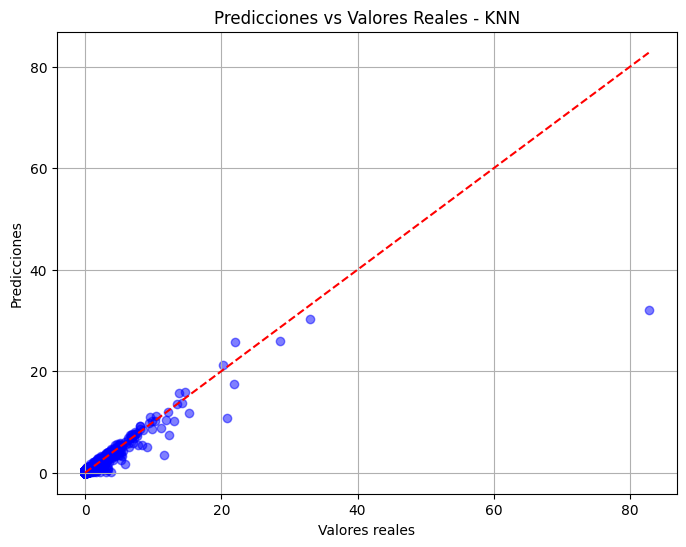

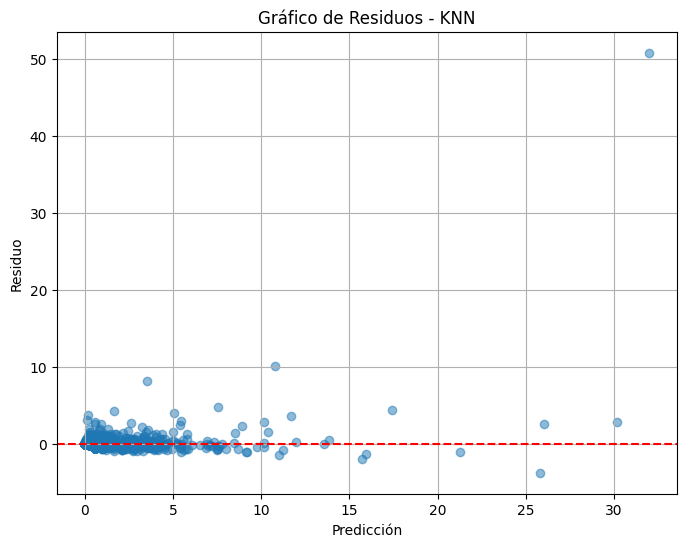

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Entrenar modelo KNN
modelo_knn = KNeighborsRegressor(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)

# Predicciones
y_pred_knn = modelo_knn.predict(X_test_scaled)

# Evaluación
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"Evaluación del modelo KNN:")
print(f"-MSE: {mse_knn:.2f}")
print(f"- R²: {r2_knn:.2f}")

# Gráfico: Predicción vs Real
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.5, color='blue')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales - KNN")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()

# Gráfico: Residuos
residuos_knn = y_test - y_pred_knn
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_knn, residuos_knn, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Gráfico de Residuos - KNN")
plt.grid(True)
plt.show()

Evaluación del modelo de regresión lineal:
Error Cuadrático Medio (MSE): 0.11
Coeficiente de determinación R²: 0.97


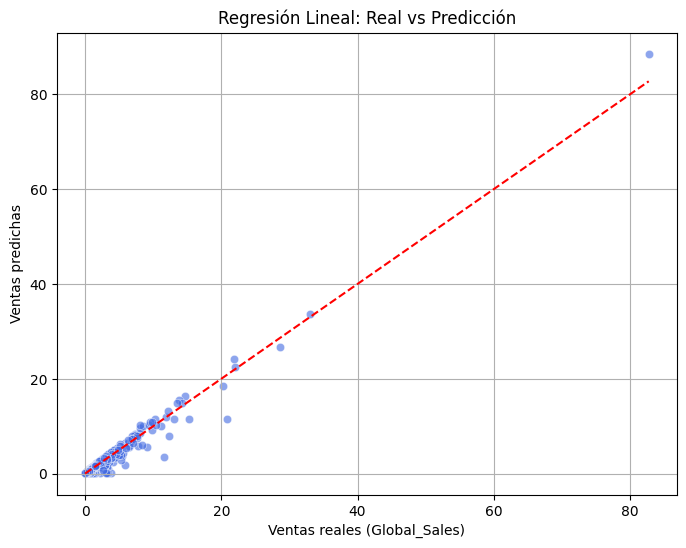

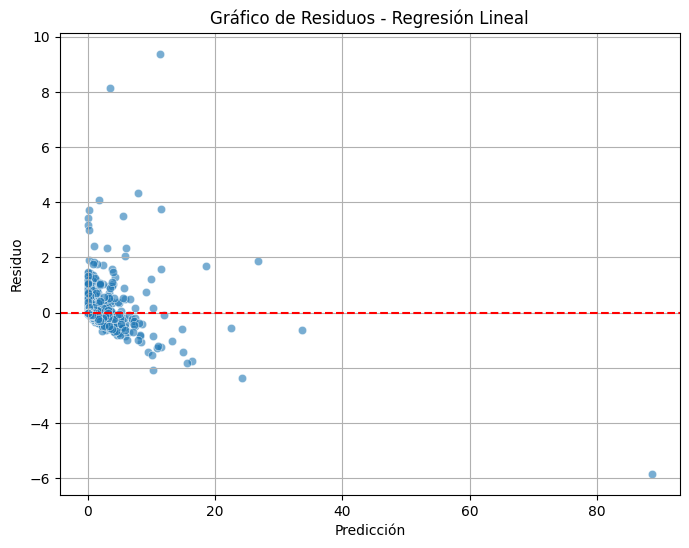

In [ ]:
# --- Librerías necesarias ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Variables predictoras y objetivo ---
features = ['NA_Sales', 'EU_Sales']
X = df[features]
y = df['Global_Sales']

# --- División entrenamiento / prueba ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#-------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Modelo de regresión lineal ---
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# --- Predicción y evaluación ---
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo de regresión lineal:")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación R²: {r2:.2f}")

# --- Visualización: Real vs Predicción ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Ventas reales (Global_Sales)")
plt.ylabel("Ventas predichas")
plt.title("Regresión Lineal: Real vs Predicción")
plt.grid(True)
plt.show()

# --- Visualización: Residuos ---
residuos = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuos, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Gráfico de Residuos - Regresión Lineal")
plt.grid(True)
plt.show()

## 8. Conclusiones

Durante el desarrollo de este proyecto se construyeron y compararon dos modelos de regresión: Regresión Lineal y K-Nearest Neighbors (KNN), con el objetivo de predecir las ventas globales de videojuegos.

Ambos modelos fueron entrenados con variables como Plataforma, Género y Publisher, y evaluados usando métricas de rendimiento. La Regresión Lineal presentó un desempeño aceptable, aunque con limitaciones debido a la naturaleza no lineal de los datos. Por otro lado, el modelo KNN demostró mayor capacidad de ajuste, especialmente en datos con patrones más complejos.

En general, KNN se perfila como una mejor opción para este conjunto de datos, aunque requiere mayor poder computacional. Se recomienda seguir explorando otros algoritmos más robustos como Random Forest o XGBoost en futuras etapas, además de incorporar nuevas variables que puedan mejorar la capacidad predictiva.

Finalmente, los resultados fueron exportados para su uso en herramientas de visualización como Looker Studio, lo que permitirá una mejor toma de decisiones basada en datos.
.

# Continuacion para Evaluacion 3
Comparación KNN vs Regresión Lineal + Exportación

📌 Comparación - Primeras filas:


,Real,Regresión Lineal,KNN,Error RL,Error KNN
3527,0.57,0.640265,0.610,0.070265,0.040
12216,0.07,0.085174,0.060,0.015174,0.010
7940,0.19,0.028811,0.594,0.161189,0.404
3030,0.67,0.759725,0.610,0.089725,0.060
7144,0.22,0.297160,0.232,0.077160,0.012


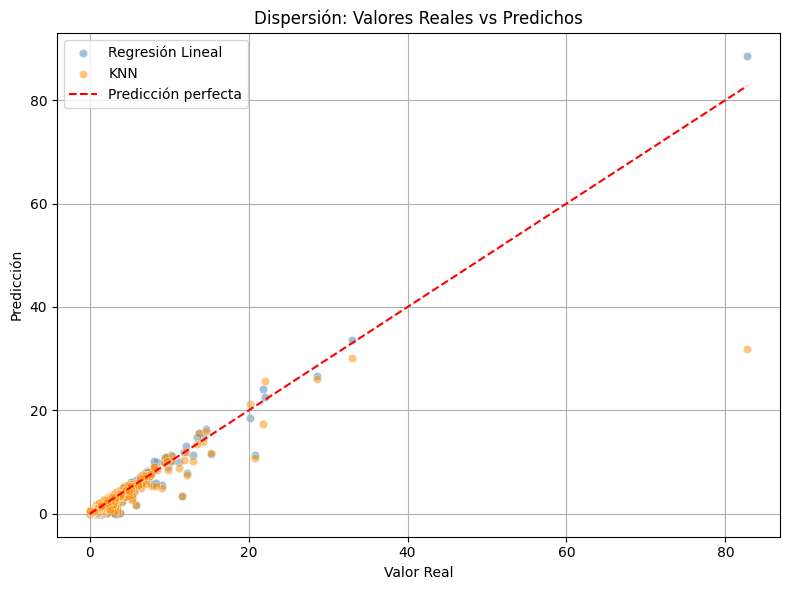

✅ Modelos guardados en formato .pkl
✅ CSV exportado: datasetpallooker_con_predicciones_20250704.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display
from datetime import datetime

# --- Comparación: Real vs Predicciones ---
comparacion_modelos = pd.DataFrame({
    'Real': y_test,
    'Regresión Lineal': y_pred,
    'KNN': y_pred_knn
})
comparacion_modelos['Error RL'] = np.abs(comparacion_modelos['Real'] - comparacion_modelos['Regresión Lineal'])
comparacion_modelos['Error KNN'] = np.abs(comparacion_modelos['Real'] - comparacion_modelos['KNN'])

print("📌 Comparación - Primeras filas:")
display(comparacion_modelos.head())


# --- Gráfico Real vs Predicción ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Real', y='Regresión Lineal', data=comparacion_modelos, label='Regresión Lineal', alpha=0.5, color='steelblue')
sns.scatterplot(x='Real', y='KNN', data=comparacion_modelos, label='KNN', alpha=0.5, color='darkorange')
plt.plot([comparacion_modelos['Real'].min(), comparacion_modelos['Real'].max()],
         [comparacion_modelos['Real'].min(), comparacion_modelos['Real'].max()],
         'r--', label='Predicción perfecta')
plt.title("Dispersión: Valores Reales vs Predichos")
plt.xlabel("Valor Real")
plt.ylabel("Predicción")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Guardar modelos entrenados en Pickle ---
fecha_actual = datetime.now().strftime('%Y%m%d')

with open(f'modelo_knn_{fecha_actual}.pkl', 'wb') as f_knn:
    pickle.dump(modelo_knn, f_knn)

with open(f'modelo_regresion_lineal_{fecha_actual}.pkl', 'wb') as f_rl:
    pickle.dump(model, f_rl)

print("✅ Modelos guardados en formato .pkl")

# --- Exportar CSV para Looker con predicciones ---
# Aquí se usa el df original, que tiene las categorías ya encodificadas a números.
# Necesitamos usar df_para_exportar que hicimos una copia antes.

# X_full y X_full_scaled se usan para las predicciones, y deben usar el df con encoding.

X_full = df[['NA_Sales', 'EU_Sales']] # <-- Aquí df está bien porque ya tiene NA_Sales y EU_Sales numéricas
X_full_scaled = scaler.transform(X_full)

# Las predicciones se asignan al df que tiene el encoding numérico, lo cual es correcto
df['Pred_KNN'] = modelo_knn.predict(X_full_scaled)
df['Pred_Regresion_Lineal'] = model.predict(X_full_scaled)


# Columnas necesarias + predicciones
columnas_looker = ['Platform', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Pred_KNN', 'Pred_Regresion_Lineal']

# En lugar de usar df[columnas_looker].copy(), se debe construir el DataFrame para Looker
# usando las columnas categóricas de df_para_exportar y las predicciones del df original.

# Crear un nuevo DataFrame para Looker combinando lo necesario
df_looker = pd.DataFrame()
df_looker['Platform'] = df_para_exportar['Platform']
df_looker['Genre'] = df_para_exportar['Genre']
df_looker['Publisher'] = df_para_exportar['Publisher']
df_looker['NA_Sales'] = df_para_exportar['NA_Sales'] # O de df, ya que no se modifican
df_looker['EU_Sales'] = df_para_exportar['EU_Sales'] # Ídem
df_looker['JP_Sales'] = df_para_exportar['JP_Sales'] # Ídem
df_looker['Other_Sales'] = df_para_exportar['Other_Sales'] # Ídem
df_looker['Global_Sales'] = df_para_exportar['Global_Sales'] # Ídem

# Las predicciones vienen del 'df' que tiene las predicciones ya calculadas
df_looker['Pred_KNN'] = df['Pred_KNN']
df_looker['Pred_Regresion_Lineal'] = df['Pred_Regresion_Lineal']


nombre_archivo = f'datasetpallooker_con_predicciones_{fecha_actual}.csv'
df_looker.to_csv(nombre_archivo, index=False, encoding='utf-8')
print(f"✅ CSV exportado: {nombre_archivo}")